In [68]:
import pandas as pd
import numpy as np

# Create data dictionary
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'Department': ['HR', 'Engineering', 'Engineering', 'Marketing', 'HR', 'Engineering'],
    'Age': [28, 34, np.nan, 41, 23, 38], # np.nan represents a missing value
    'Salary': [55000, 95000, 88000, np.nan, 48000, 105000]
}

# Load into a DataFrame
df = pd.DataFrame(data)
print("Initial DataFrame:\n", df)

Initial DataFrame:
       Name   Department   Age    Salary
0    Alice           HR  28.0   55000.0
1      Bob  Engineering  34.0   95000.0
2  Charlie  Engineering   NaN   88000.0
3    David    Marketing  41.0       NaN
4      Eva           HR  23.0   48000.0
5    Frank  Engineering  38.0  105000.0


In [69]:
# 1. Grab Bob's data using row index position 1 (.iloc)
print(df.iloc[1])

# 2. Grab only the 'Name' and 'Salary' columns for the first 3 employees (.loc)
# Syntax is df.loc[row_labels, column_labels]
print(df.loc[0:2, ['Name', 'Salary']])

# 3. Pull out Charlie's Salary specifically using .at or .loc
print(df.loc[2, 'Salary'])

Name                  Bob
Department    Engineering
Age                  34.0
Salary            95000.0
Name: 1, dtype: object
      Name   Salary
0    Alice  55000.0
1      Bob  95000.0
2  Charlie  88000.0
88000.0


In [70]:
# 1. Check which individual cells are empty (returns True/False map)
print(df.isna())

# 2. Count exactly how many missing values exist in EACH column
print(df.isna().sum())

# 3. Isolate rows where the 'Age' column is missing completely
missing_age_rows = df[df['Age'].isna()]
print("\nRows missing age:\n", missing_age_rows)

    Name  Department    Age  Salary
0  False       False  False   False
1  False       False  False   False
2  False       False   True   False
3  False       False  False    True
4  False       False  False   False
5  False       False  False   False
Name          0
Department    0
Age           1
Salary        1
dtype: int64

Rows missing age:
       Name   Department  Age   Salary
2  Charlie  Engineering  NaN  88000.0


In [71]:
# Create a second auxiliary dataframe containing managers for each department
mgr_data = {
    'Department': ['HR', 'Engineering', 'Marketing'],
    'Manager': ['Sarah', 'John', 'Alex']
}
df_managers = pd.DataFrame(mgr_data)

# Merge the original employee DataFrame with the manager DataFrame on the matching column
# This functions like an SQL JOIN operation
merged_df = pd.merge(df, df_managers, on='Department', how='left')
print("\nFully Merged Table with Manager data:\n", merged_df)


Fully Merged Table with Manager data:
       Name   Department   Age    Salary Manager
0    Alice           HR  28.0   55000.0   Sarah
1      Bob  Engineering  34.0   95000.0    John
2  Charlie  Engineering   NaN   88000.0    John
3    David    Marketing  41.0       NaN    Alex
4      Eva           HR  23.0   48000.0   Sarah
5    Frank  Engineering  38.0  105000.0    John


##: Comprehensive Practice Quiz & Review Check

In [72]:
quiz_df = pd.DataFrame({
    'Product': ['Laptop', 'Mouse', 'Monitor', 'Keyboard', 'Laptop', 'Monitor'],
    'Store': ['North', 'North', 'South', 'South', 'South', 'North'],
    'Price': [1200, 25, np.nan, 75, 1150, 300],
    'Quantity': [5, 20, 7, np.nan, 4, 12]
})

#:  The Questions: Write custom lines of pandas operations to output the following:

Question 1: Write a command that prints out the row count and column count of this table.

Question 2: Isolate and print only rows where the Price column contains a missing value.

Question 3: Calculate the total revenue (Price multiplied by Quantity) for each row without loops, saving it as a new column called Revenue.

Question 4: Group the data by Product and calculate the total quantity sold for each product item across all stores.

In [73]:
print (quiz_df)

    Product  Store   Price  Quantity
0    Laptop  North  1200.0       5.0
1     Mouse  North    25.0      20.0
2   Monitor  South     NaN       7.0
3  Keyboard  South    75.0       NaN
4    Laptop  South  1150.0       4.0
5   Monitor  North   300.0      12.0


In [75]:
print (quiz_df[quiz_df['Price'].isna()])

   Product  Store  Price  Quantity
2  Monitor  South    NaN       7.0


In [76]:
# .shape returns a tuple: (rows, columns)
dimensions = quiz_df.shape
print(f"The table has {dimensions[0]} rows and {dimensions[1]} columns.")

The table has 6 rows and 4 columns.


In [77]:
# Create a boolean mask where Price is NaN, then filter the DataFrame
missing_price_df = quiz_df[quiz_df['Price'].isna()]
print(missing_price_df)

   Product  Store  Price  Quantity
2  Monitor  South    NaN       7.0


In [78]:
# Element-wise multiplication automatically spreads down the columns
quiz_df['Revenue'] = quiz_df['Price'] * quiz_df['Quantity']
print(quiz_df)

    Product  Store   Price  Quantity  Revenue
0    Laptop  North  1200.0       5.0   6000.0
1     Mouse  North    25.0      20.0    500.0
2   Monitor  South     NaN       7.0      NaN
3  Keyboard  South    75.0       NaN      NaN
4    Laptop  South  1150.0       4.0   4600.0
5   Monitor  North   300.0      12.0   3600.0


In [79]:
# Split by Product -> Select Quantity column -> Apply Sum function
total_sold = quiz_df.groupby('Product')['Quantity'].sum()
print(total_sold)

Product
Keyboard     0.0
Laptop       9.0
Monitor     19.0
Mouse       20.0
Name: Quantity, dtype: float64


In [80]:
import pandas as pd
import numpy as np

# Setup data dictionary
orders_data = {
    'OrderID': ['ORD001', 'ORD002', 'ORD003', 'ORD004', 'ORD005'],
    'Customer': ['Yusuf', 'Emma', 'Sofia', 'Liam', 'Mooky'],
    'Region': ['North', 'East', 'South', 'West', 'East'],
    'Spend': [250.50, 45.00, 899.00, 12.75, 550.00],
    'Items': [3, 1, 5, 1, 4]
}

## 
Task 1.1: Convert the orders_data dictionary into a Pandas DataFrame called orders_df. Set the OrderID column as the formal index of the table using .set_index(). Print the table.

Task 1.2: Use label-based indexing (.loc) to extract and print only the rows for ORD002 and ORD005, showing just their Customer and Spend columns.

Task 1.3: Use integer-based indexing (.iloc) to slice the table down to its first 3 rows and its last 2 columns.

In [81]:
# Task 1.1: Creation and indexing
orders_df = pd.DataFrame(orders_data).set_index('OrderID')
print("Task 1.1 Output:\n", orders_df)

Task 1.1 Output:
         Customer Region   Spend  Items
OrderID                               
ORD001     Yusuf  North  250.50      3
ORD002      Emma   East   45.00      1
ORD003     Sofia  South  899.00      5
ORD004      Liam   West   12.75      1
ORD005     Mooky   East  550.00      4


In [82]:
# Task 1.2: Precise label slicing
label_slice = orders_df.loc[['ORD002', 'ORD005'], ['Customer', 'Spend']]
print("\nTask 1.2 Output:\n", label_slice)


Task 1.2 Output:
         Customer  Spend
OrderID                
ORD002      Emma   45.0
ORD005     Mooky  550.0


In [83]:
# Task 1.3: Positional coordinate slicing
position_slice = orders_df.iloc[0:3, -2:]
print("\nTask 1.3 Output:\n", position_slice)


Task 1.3 Output:
          Spend  Items
OrderID              
ORD001   250.5      3
ORD002    45.0      1
ORD003   899.0      5


In [84]:
# Dirty hospital log data
patient_data = {
    'PatientID': [101, 102, 103, 104, 105, 106],
    'Name': ['Anna', 'Ben', 'Charlie', 'Diana', 'Ethan', 'Fiona'],
    'Age': [34, np.nan, 45, np.nan, 29, 61],
    'Cholesterol': [180, 210, np.nan, np.nan, 195, 240],
    'SmokerStatus': ['No', 'yes', 'No', 'no', 'YES', 'No']
}
hospital_df = pd.DataFrame(patient_data)

## 
Task 2.1: Detect the damage. Print out a summary showing the exact number of missing (NaN) values residing in each column.

Task 2.2: Isolate the worst records. Filter out and print only the rows where both the Age and Cholesterol fields are missing simultaneously. (Hint: use the bitwise AND operator & along with .isna()).

Task 2.3: Fill the gaps. Replace all missing values in the Age column with the median age of the other patients, and save the changes permanently.

Task 2.4: Standardize the strings. The SmokerStatus column has inconsistent styling (yes, YES, no, No). Use .str.upper() to force all text strings in that column into uppercase uniform values.

In [85]:
# Task 2.1: Missing value diagnosis
print("Task 2.1 Output (Null Counts):\n", hospital_df.isna().sum())

Task 2.1 Output (Null Counts):
 PatientID       0
Name            0
Age             2
Cholesterol     2
SmokerStatus    0
dtype: int64


In [90]:
worse_record = hospital_df[hospital_df['Age'].isna() & hospital_df['Cholesterol'].isna()]
print(worse_record)

   PatientID   Name  Age  Cholesterol SmokerStatus
3        104  Diana  NaN          NaN           no


In [91]:
# Task 2.3: Imputing values using statistical median
age_median = hospital_df['Age'].median()
hospital_df['Age'] = hospital_df['Age'].fillna(age_median)
print("\nTask 2.3 Output (Ages Cleaned):\n", hospital_df[['Name', 'Age']])


Task 2.3 Output (Ages Cleaned):
       Name   Age
0     Anna  34.0
1      Ben  39.5
2  Charlie  45.0
3    Diana  39.5
4    Ethan  29.0
5    Fiona  61.0


In [92]:
# Task 2.4: Text harmonization/capitalization
hospital_df['SmokerStatus'] = hospital_df['SmokerStatus'].str.upper()
print("\nTask 2.4 Output (Cleaned Table):\n", hospital_df)


Task 2.4 Output (Cleaned Table):
    PatientID     Name   Age  Cholesterol SmokerStatus
0        101     Anna  34.0        180.0           NO
1        102      Ben  39.5        210.0          YES
2        103  Charlie  45.0          NaN           NO
3        104    Diana  39.5          NaN           NO
4        105    Ethan  29.0        195.0          YES
5        106    Fiona  61.0        240.0           NO


#   plot graph

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
# Set a clean visual theme for all our charts
sns.set_theme(style="whitegrid")

In [96]:
# 1. Load a built-in sample dataset
tips = sns.load_dataset('tips')
print("Sample of Data:\n", tips.head())

Sample of Data:
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


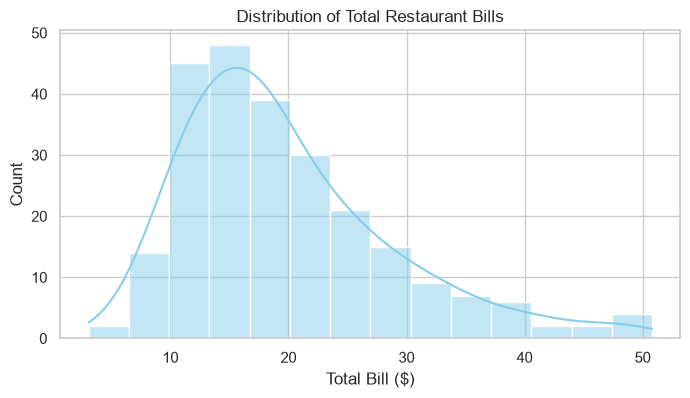

In [97]:
# 2. Histogram: See the distribution of total bills
plt.figure(figsize=(8, 4))
sns.histplot(data=tips, x='total_bill', kde=True, color='skyblue')
plt.title('Distribution of Total Restaurant Bills')
plt.xlabel('Total Bill ($)')
plt.show()

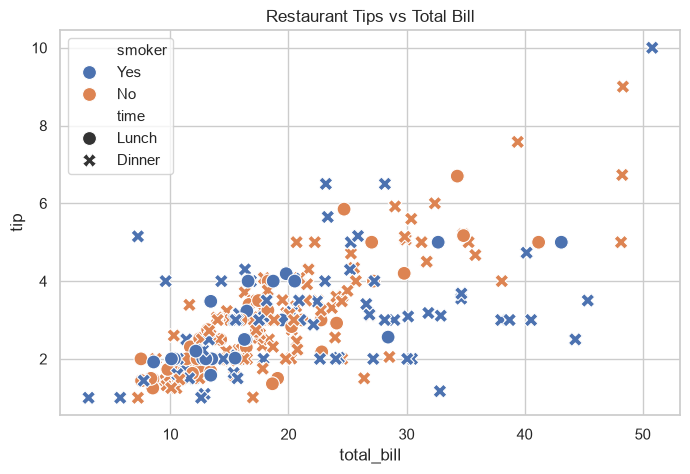

In [98]:
# 3. Scatter Plot with 'Hue': Relationship between Bill and Tip
# 'hue' automatically color-codes the dots by a third category (e.g., Smoker vs Non-Smoker)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', style='time', s=100)
plt.title('Restaurant Tips vs Total Bill')
plt.show()

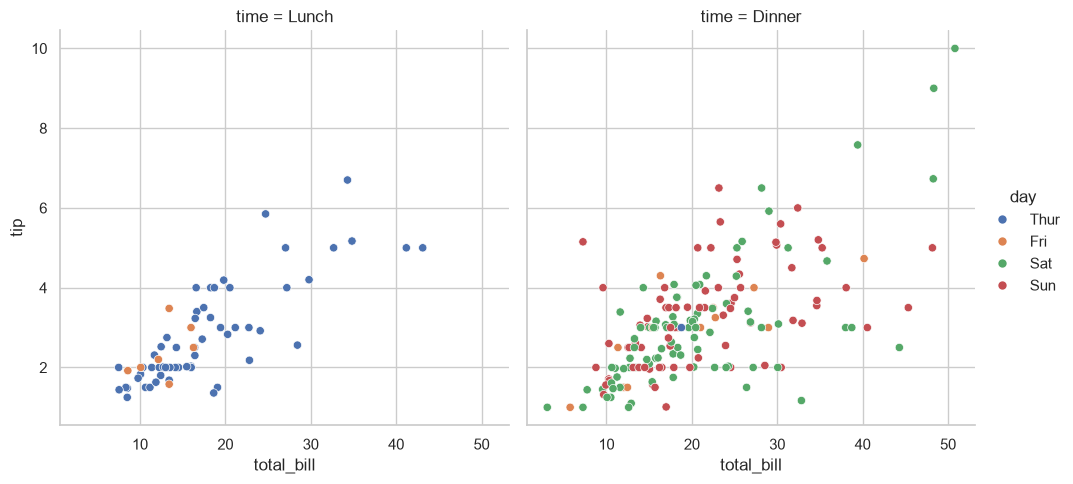

In [99]:
# 1. Relplot with Column Mapping: Creates side-by-side charts automatically
# This splits the data into separate charts for Lunch and Dinner
sns.relplot(data=tips, x='total_bill', y='tip', hue='day', col='time', kind='scatter')
plt.show()

C:\Users\lu_zh\AppData\Local\Temp\ipykernel_12964\2335709142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', palette='Set2')


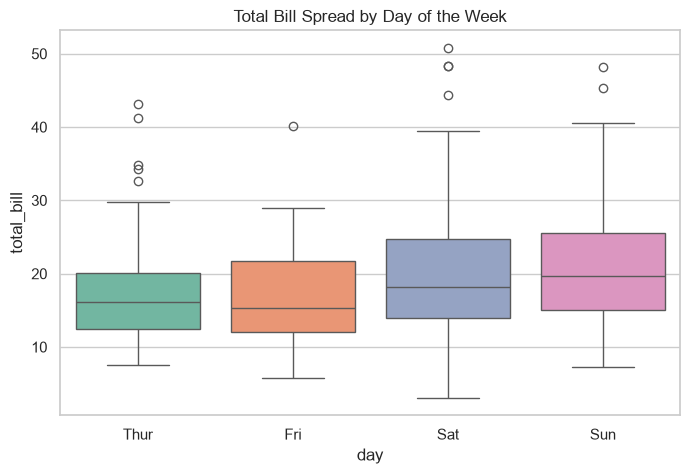

In [100]:
# 2. Box Plot: Compare total bills across different days of the week to spot outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x='day', y='total_bill', palette='Set2')
plt.title('Total Bill Spread by Day of the Week')
plt.show()

In [101]:
# 1. Filter out non-numeric categories to prevent errors
numeric_df = tips.select_dtypes(include=[np.number])

In [102]:
# 2. Calculate the correlation matrix (-1 means opposite trend, +1 means perfect sync)
corr_matrix = numeric_df.corr()
print("Correlation Matrix Table:\n", corr_matrix)

Correlation Matrix Table:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


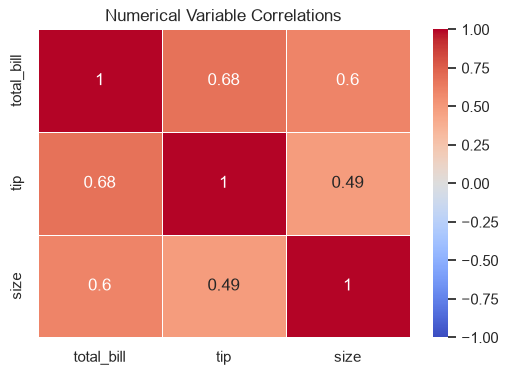

In [103]:
# 3. Generate the Heatmap
plt.figure(figsize=(6, 4))
# annot=True puts the actual numbers inside the squares, cmap sets the color scheme
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Numerical Variable Correlations')
plt.show()

In [104]:
flights = sns.load_dataset('flights')
print("Sample of Data:\n", flights.head())

Sample of Data:
    year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


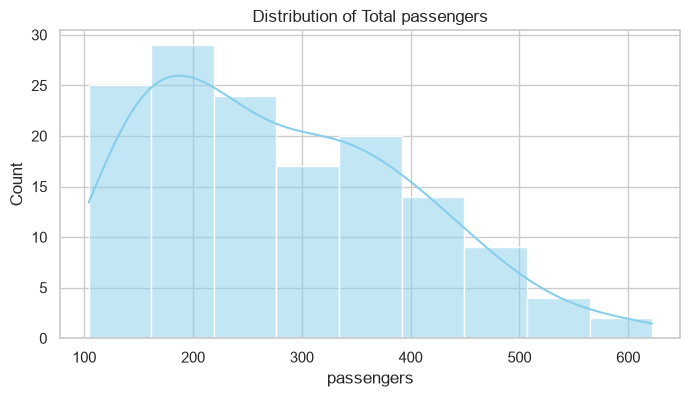

In [105]:
# 2. Histogram: See the distribution of passengers
plt.figure(figsize=(8, 4))
sns.histplot(data=flights, x='passengers', kde=True, color='skyblue')
plt.title('Distribution of Total passengers')
plt.xlabel('passengers')
plt.show()

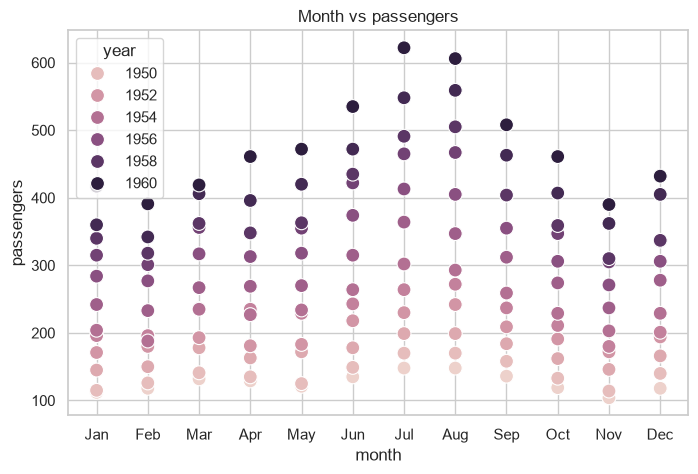

In [107]:
# 3. Scatter Plot with 'Hue': Relationship between Bill and Tip
# 'hue' automatically color-codes the dots by a third category (e.g., Smoker vs Non-Smoker)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=flights, x='month', y='passengers', hue='year', s=100)
plt.title('Month vs passengers')
plt.show()

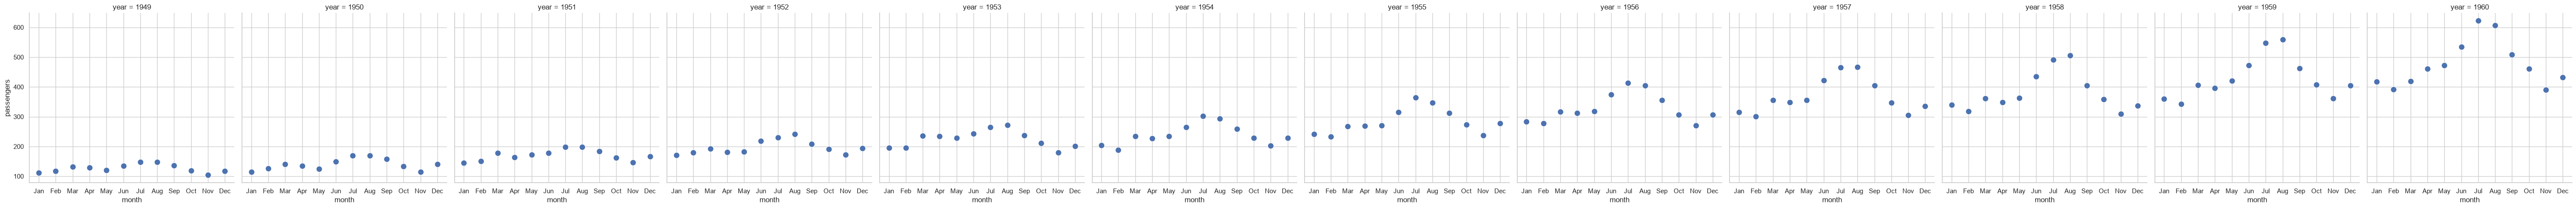

In [111]:
# 1. Relplot with Column Mapping: Creates side-by-side charts automatically
# This splits the data into separate charts for Lunch and Dinner
sns.relplot(data=flights,  x='month', y='passengers',  col='year', kind='scatter', s=100)
plt.show()

C:\Users\lu_zh\AppData\Local\Temp\ipykernel_12964\27379828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=flights, x='month', y='passengers', palette='Set2')


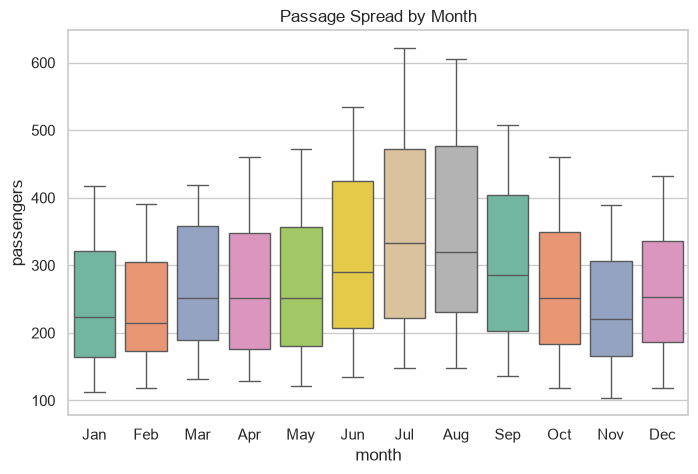

In [112]:
# 2. Box Plot: Compare total bills across different days of the week to spot outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=flights, x='month', y='passengers', palette='Set2')
plt.title('Passage Spread by Month')
plt.show()

In [113]:
# 1. Filter out non-numeric categories to prevent errors
numeric_df = flights.select_dtypes(include=[np.number])

In [114]:
# 2. Calculate the correlation matrix (-1 means opposite trend, +1 means perfect sync)
corr_matrix = numeric_df.corr()
print("Correlation Matrix Table:\n", corr_matrix)

Correlation Matrix Table:
                 year  passengers
year        1.000000    0.921824
passengers  0.921824    1.000000


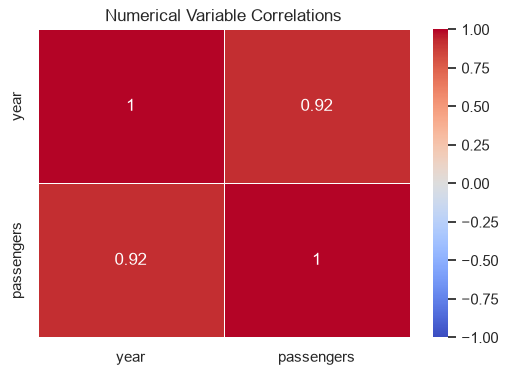

In [115]:
# 3. Generate the Heatmap
plt.figure(figsize=(6, 4))
# annot=True puts the actual numbers inside the squares, cmap sets the color scheme
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Numerical Variable Correlations')
plt.show()